<a href="https://colab.research.google.com/github/Malicef/redes_neurais/blob/main/multilayerPerceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
labels =['comprimento_sepala', 'largura_sepala', 'comprimento_petala', 'largura_petala', 'classe']
df.columns = labels
df.head(5)

,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,classe
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
classes = df ['classe'].unique()

In [5]:
entrada = df.iloc[:, 0:4].values
saida_desejada = df['classe'].values

In [6]:
dados_treino, dados_teste, saida_treino, saida_teste = train_test_split(entrada, saida_desejada, test_size=0.2)

In [7]:
sc = StandardScaler()
sc.fit(dados_treino)
dados_treino_padronizados = sc.fit_transform(dados_treino)
dados_teste_padronizados = sc.transform(dados_teste)

In [9]:
saida_treino_onehot = pd.get_dummies(saida_treino).values
saida_teste_onehot = pd.get_dummies(saida_teste).values

In [28]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(64, input_dim=4, activation='sigmoid', name='oculta'))
modelo.add(tf.keras.layers.Dense(3, activation='softmax', name='saida'))
modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta (Dense)                  │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['mse'])

In [30]:
historico = modelo.fit(dados_treino_padronizados, saida_treino_onehot, validation_split=0.2, epochs=60, batch_size=10)

Epoch 1/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.0150 - mse: 0.2012 - val_loss: 0.7213 - val_mse: 0.1332
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6380 - mse: 0.1202 - val_loss: 0.5389 - val_mse: 0.1021
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4687 - mse: 0.0863 - val_loss: 0.4353 - val_mse: 0.0835
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3836 - mse: 0.0716 - val_loss: 0.3973 - val_mse: 0.0767
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3401 - mse: 0.0640 - val_loss: 0.3549 - val_mse: 0.0686
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3018 - mse: 0.0576 - val_loss: 0.3281 - val_mse: 0.0659
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2617 - mse: 0.0472 - val_loss: 0.3182 - val_mse: 0.0597
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2567 - mse: 0.0482 - val_loss: 0.2827 - val_mse: 0.0551
Epoch 9/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2232 

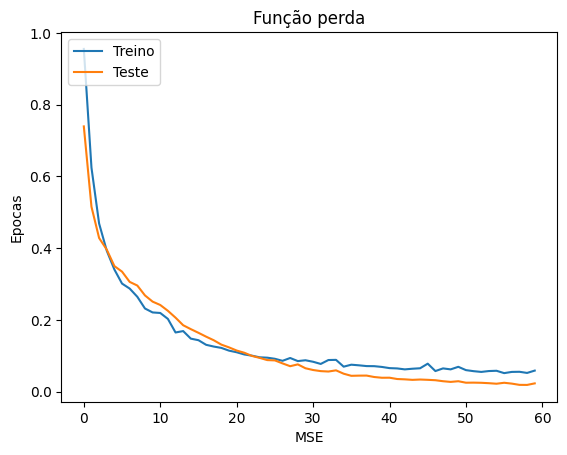

In [27]:
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Função perda')
plt.xlabel('MSE')
plt.ylabel('Epocas')
plt.legend(['Treino', 'Teste'], loc='upper left')

In [23]:
teste = np.array([[5.1, 3.5, 1.4, 0.2]])
teste = sc.transform(teste)

y_predd = modelo.predict(teste)
y_predd = np.argmax(y_predd, axis=1)+1
print("A classe é: ", y_predd[-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
A classe é:  1
